In [3]:
import numpy as np
import yfinance as yf
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from scipy import stats
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox

from GBM import *

In [4]:
my_picks = ['AAPL', # Apple Inc. - Information Technology,
            'AMZN', # Amazon - Consumer Discretionary
            'F', # Ford Motor Company - Consumer Discretionary
            'KO', # Coca-Cola Company (The) - Consumer Staples
            'XOM', # ExxonMobil - Energy
            'JPM', # JPMorgan Chase - Financials,
            'PFE', #Pfizer - Health Care,
            'BA', # Boeing - Industrials
            'DD', # DuPont - Materials
            'NRG'] # NRG Energy - Utilities

In [6]:
# # Either download and save the equity data
# dataSave = yf.download(my_picks, start="2015-01-01", end="2025-05-01",auto_adjust=True)
# dataSave.to_parquet('yfinance_selected.parquet')

# # Or read a previously saved copy
# dataSave = pd.read_parquet('yfinance_selected.parquet')

close = dataSave['Close'].copy()
close

Ticker,AAPL,AMZN,BA,DD,F,JPM,KO,NRG,PFE,XOM
Date,,,,,,,,,,
2015-01-02,24.192604,15.426000,113.657211,20.801046,8.331915,46.274319,29.580019,21.374203,18.082529,57.145561
2015-01-05,23.511057,15.109500,112.870049,20.157717,8.006448,44.837734,29.580019,20.558096,17.984413,55.581955
2015-01-06,23.513275,14.764500,111.540649,19.833765,7.930506,43.675144,29.804630,20.293835,18.134476,55.286457
2015-01-07,23.842976,14.921000,113.272377,19.801819,8.158329,43.741776,30.176666,20.387102,18.382650,55.846653
2015-01-08,24.759077,15.023000,115.275276,20.294586,8.364458,44.719234,30.541677,20.837904,18.757803,56.776207
...,...,...,...,...,...,...,...,...,...,...
2025-04-24,207.274811,186.539993,176.259995,26.972361,9.449337,239.972992,70.476967,104.488777,20.893494,104.313507
2025-04-25,208.180023,188.990005,177.949997,26.825350,9.430551,238.903809,69.884163,106.674858,21.021900,104.255898
2025-04-28,209.035507,187.699997,182.300003,26.817183,9.411765,238.580093,69.767532,107.689117,21.141132,104.313507


In [4]:
# Fit normal distribution to log increments of price data. Run GBM monte-carlo assuming normal distribution
month_starts = make_month_grid(close)
path_containment = []
standardized_returns = []

for ticker in my_picks:
    
    tic = dt.datetime.today()
    print(ticker,tic,end=' - ')
    
    ticker_standardized_returns = []
    # Keep 3 months for coefficient estimation, also throw out 1 month for last upper bound
    for month_select in range(3,len(month_starts)-1):

        prev_data, window = isolate_data(close,ticker,month_starts,month_select)
        coefficients = estimate_normal_coefficients(prev_data)
        standardized_return = standardize_with_normal_coefficients(window,coefficients)
        ticker_standardized_returns.append(standardized_return)

        ticker_id = my_picks.index(ticker)  # or any stable integer mapping
        time_start = month_starts[month_select]
        ss = np.random.SeedSequence([ticker_id, time_start.toordinal()])
        rng = np.random.default_rng(ss)
        drift, bands, paths = simulate_paths(window,coefficients,rng)

        percentile_dict = make_percentile_dict(ticker,time_start,window,bands)
        path_containment.append(percentile_dict)

    print('Done', dt.datetime.today()-tic)
    ticker_standardized_returns = pd.concat(ticker_standardized_returns,axis=0)
    standardized_returns.append(ticker_standardized_returns)

path_containment = pd.DataFrame(path_containment).set_index(['ticker','path_start'])
standardized_returns = pd.concat(standardized_returns,axis=1)

AAPL 2026-05-15 14:05:33.047383 - Done 0:00:05.080495
AMZN 2026-05-15 14:05:38.143274 - Done 0:00:05.238519
F 2026-05-15 14:05:43.395723 - Done 0:00:05.045740
KO 2026-05-15 14:05:48.455376 - Done 0:00:05.455579
XOM 2026-05-15 14:05:53.925186 - Done 0:00:05.218069
JPM 2026-05-15 14:05:59.161240 - Done 0:00:05.631107
PFE 2026-05-15 14:06:04.807206 - Done 0:00:05.205572
BA 2026-05-15 14:06:10.026504 - Done 0:00:04.741685
DD 2026-05-15 14:06:14.781922 - Done 0:00:04.725773
NRG 2026-05-15 14:06:19.521826 - Done 0:00:04.740680


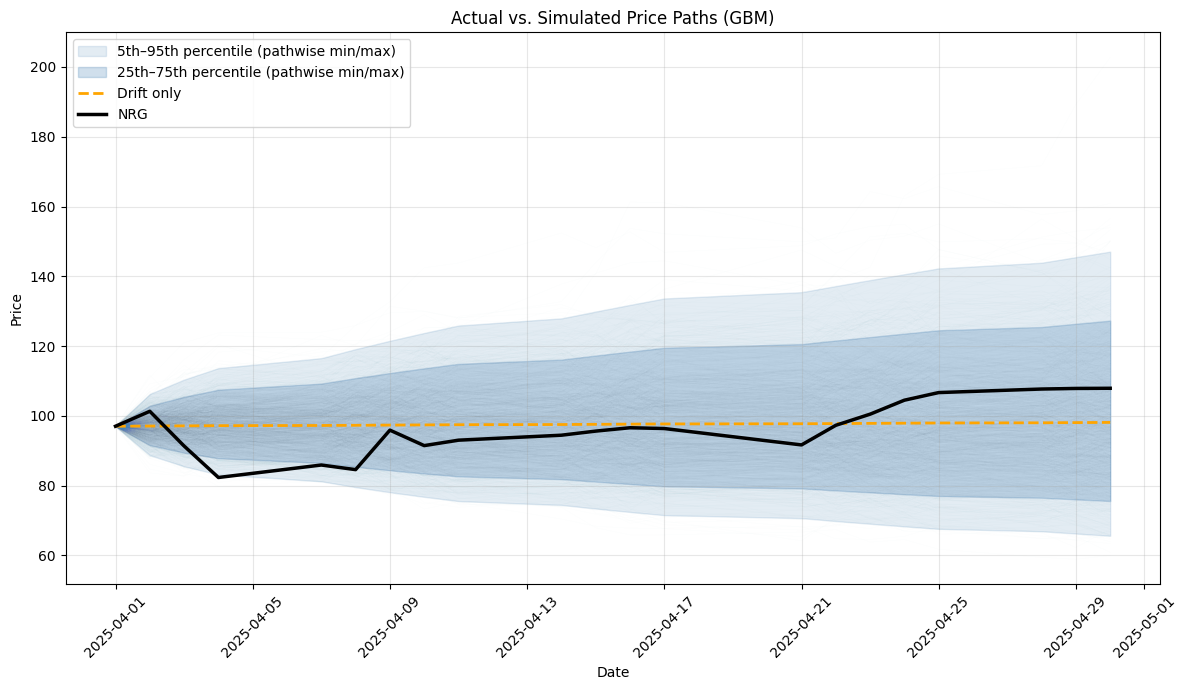

Overall Path Containment Stats (1210 trials):
p05    0.134711
p25    0.287603
p75    0.742149
p95    0.924793
dtype: float64


In [5]:
plot_bands_vs_actual(window,drift,bands,ticker,paths)
print(f'Overall Path Containment Stats ({path_containment.shape[0]} trials):\n',
      path_containment.mean(),sep='')

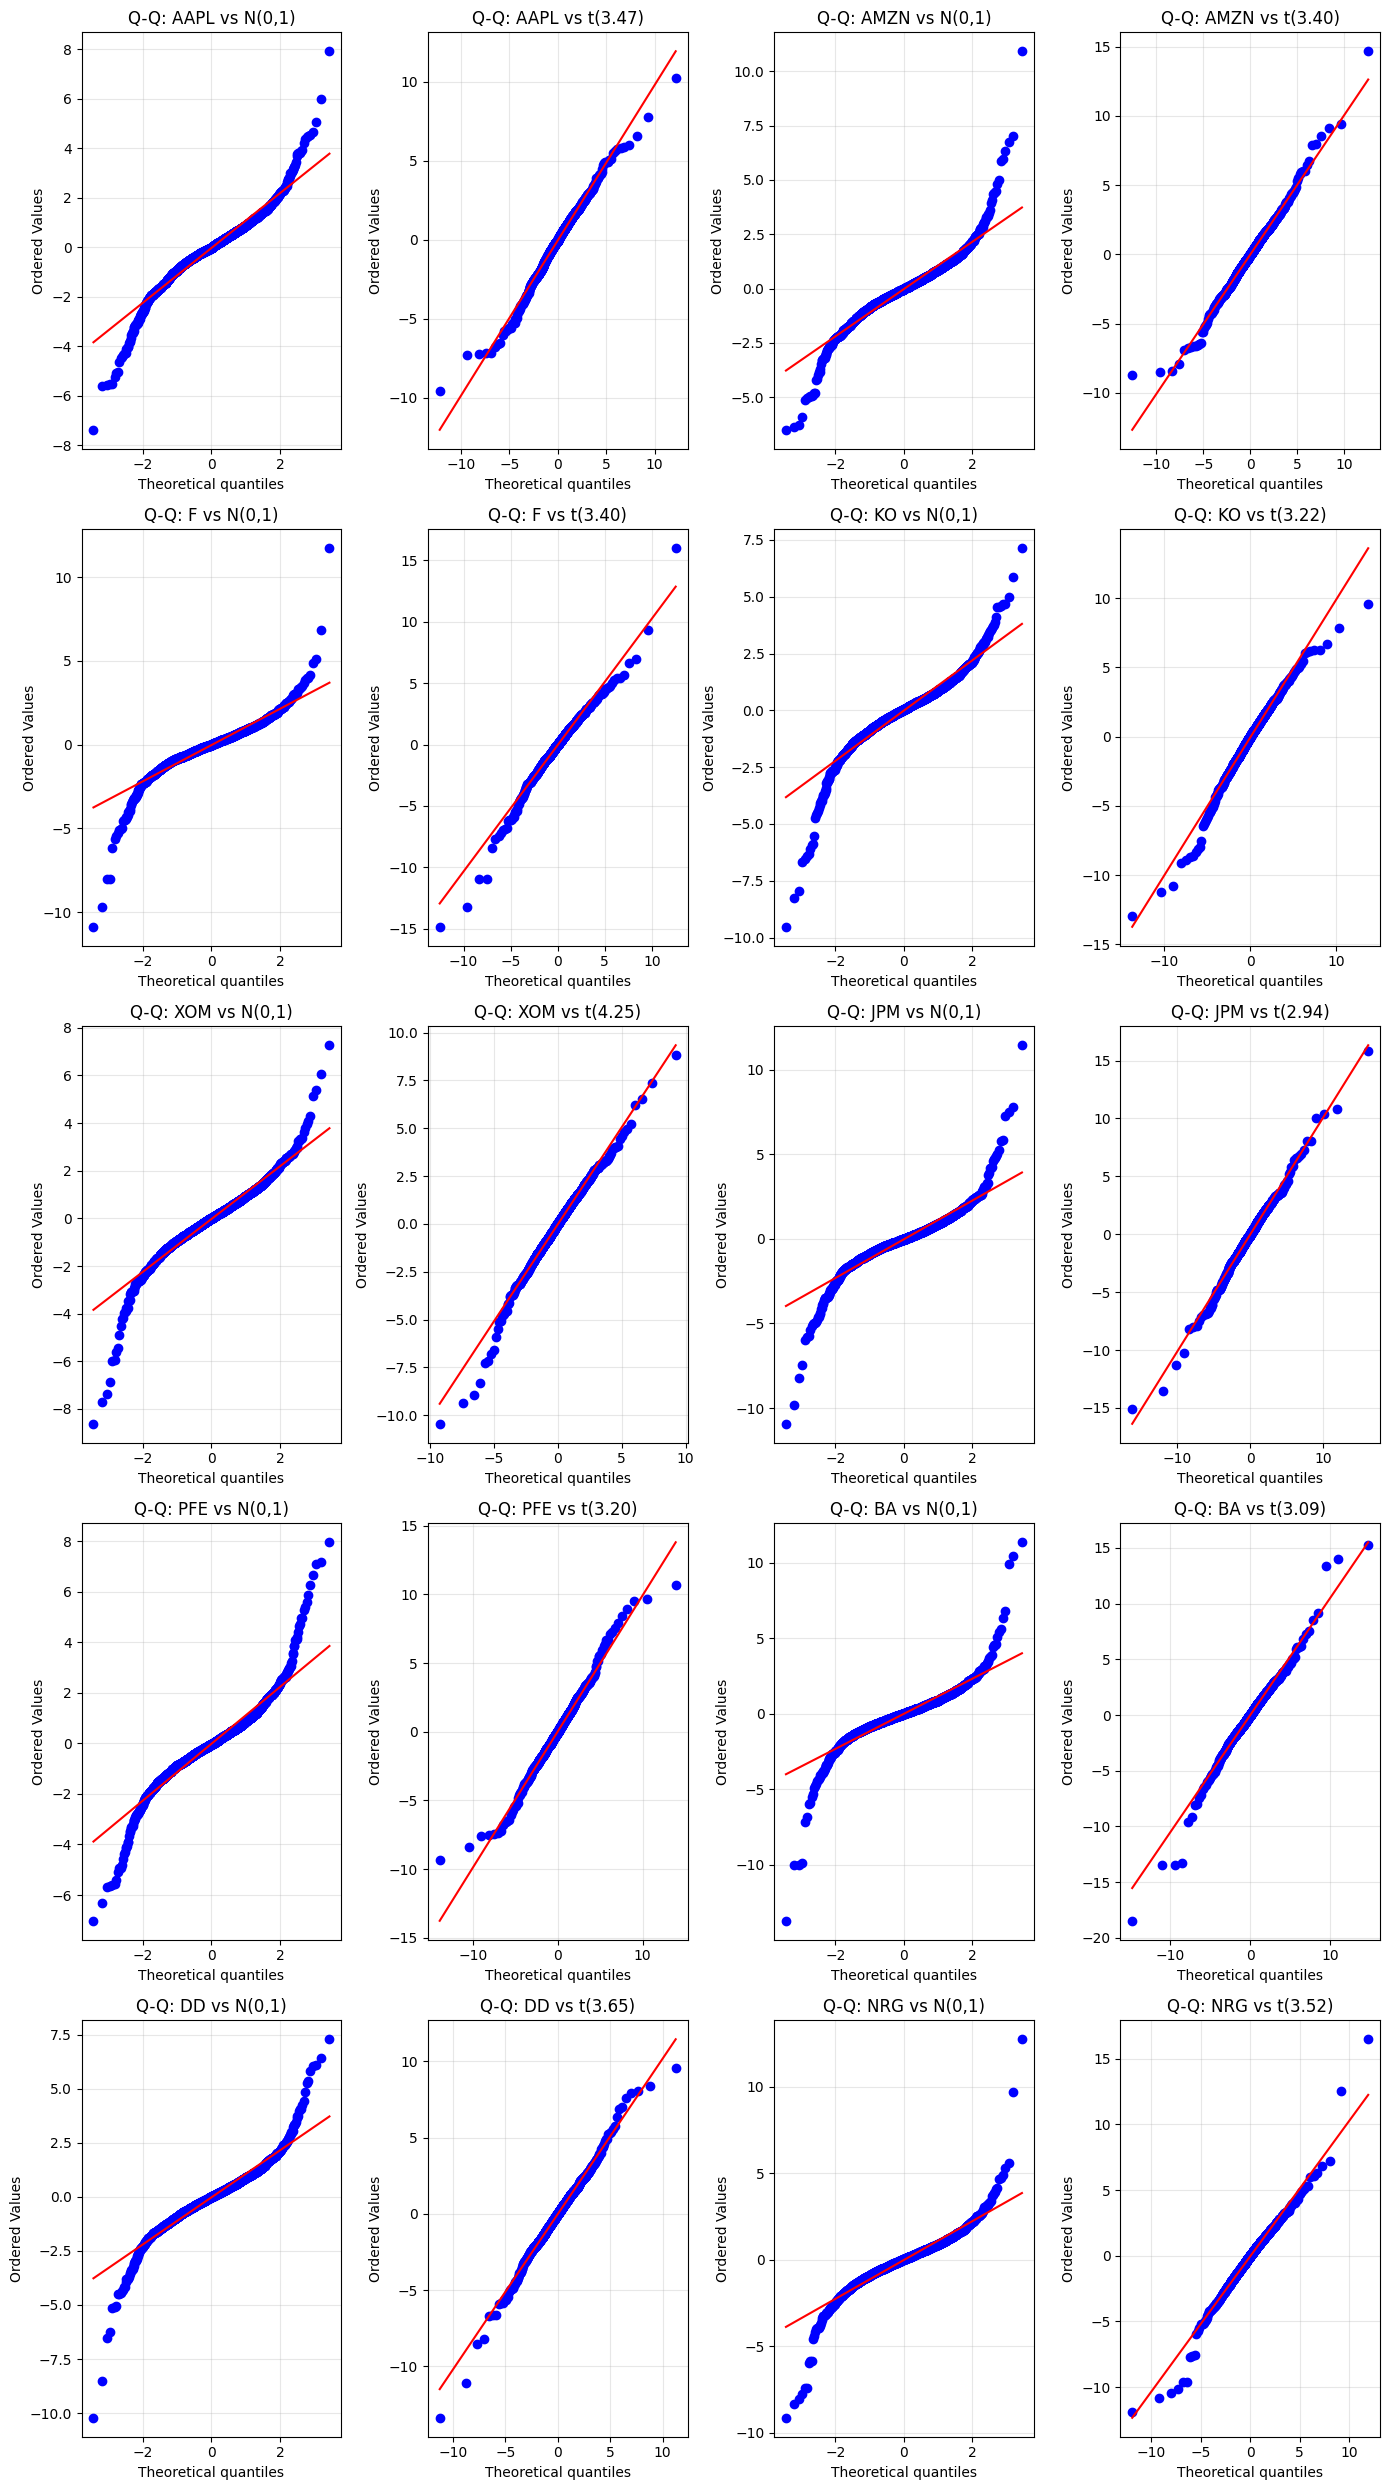

In [6]:
diag_df = qq_panel(my_picks,standardized_returns)

In [7]:
diag_df

,n,ad_norm,ad_norm_p,ad_t_pit,ad_t_pit_p
ticker,,,,,
AAPL,2415,25.786964,0.01,1.121560,0.010000
AMZN,2415,29.738430,0.01,0.340672,0.150000
F,2415,35.897305,0.01,0.486666,0.150000
KO,2415,34.473413,0.01,0.774016,0.045451
XOM,2415,17.666337,0.01,0.361715,0.150000
JPM,2415,45.389184,0.01,0.375506,0.150000
PFE,2415,32.675741,0.01,0.236743,0.150000
BA,2415,49.850182,0.01,0.335656,0.150000
DD,2415,26.527599,0.01,0.365404,0.150000


In [8]:
# Test for lagged/clustered relationship with returns, anything below .01 suggests clustering
for ticker in my_picks:
    z = standardized_returns[(ticker,'standardized returns')].dropna()
    lb = acorr_ljungbox(z**2, lags=[5, 10, 20], return_df=True)
    print(ticker, lb['lb_pvalue'].values)

AAPL [6.65811917e-079 1.47533767e-104 1.21386718e-109]
AMZN [1.21304879e-16 3.38545670e-16 5.63905358e-13]
F [1.09227818e-12 3.36380750e-19 1.58558058e-21]
KO [9.48462293e-197 0.00000000e+000 0.00000000e+000]
XOM [4.78264209e-134 6.62876569e-164 3.99194989e-198]
JPM [2.31798076e-253 0.00000000e+000 0.00000000e+000]
PFE [1.63923433e-121 1.15290427e-144 8.98444002e-143]
BA [1.09171866e-279 0.00000000e+000 0.00000000e+000]
DD [6.45368383e-65 1.19486439e-67 4.39542710e-62]
NRG [4.71789284e-64 3.14680415e-92 5.31777135e-94]


In [9]:
month_starts = make_month_grid(close)
window_results = []
path_containment = []
saved_garch_coefficients = []

for ticker in my_picks:
    
    tic = dt.datetime.today()
    print(ticker,tic,end=' - ')
    ticker_window_result = []
    garch_coefficients = None
    
    # Skip 2 years for garch coefficient fitting, also throw out 1 month for last upper bound
    for month_select in range(24,len(month_starts)-1):

        time_start = month_starts[month_select]
        prev_data, window = isolate_data(close,ticker,month_starts,month_select)

        # Fit garch coefficients once per year (look back = 2 years)
        if garch_coefficients == None or time_start.month == 1:
            garch_coefficients = fit_garch(close,ticker,month_starts,month_select)
            garch_coefficients['ticker'] = ticker
            saved_garch_coefficients.append(garch_coefficients)

        # Simulations with GARCH-t paths
        ticker_id = my_picks.index(ticker)  # or any stable integer mapping
        time_start = month_starts[month_select]
        ss = np.random.SeedSequence([ticker_id, time_start.toordinal()])
        rng = np.random.default_rng(ss)
        drift, bands, paths, sigma2 = simulate_garch_paths(window, garch_coefficients, prev_data, rng)
        percentile_dict = make_percentile_dict(ticker,time_start,window,bands)
        path_containment.append(percentile_dict)
        
        # Warm up garch on prev 3 months, then run on the selected month
        window_result = monthly_garch(garch_coefficients,prev_data,window)
        ticker_window_result.append(window_result)

        if garch_coefficients == None or time_start.month == 1:
            saved_garch_coefficients[-1]['final_trial_intial_sigma'] = window_result[(ticker,'garch sigma')].iloc[0]
            saved_garch_coefficients[-1]['final_trial_last_mean_path_sigma'] = window_result[(ticker,'garch sigma')].iloc[0]
            
    print('Done', dt.datetime.today()-tic)
    ticker_window_result = pd.concat(ticker_window_result)
    window_results.append(ticker_window_result)

window_results = pd.concat(window_results,axis=1)
path_containment = pd.DataFrame(path_containment).set_index(['ticker','path_start'])
saved_garch_coefficients = pd.DataFrame(saved_garch_coefficients)

AAPL 2026-05-15 14:06:31.470836 - Done 0:00:11.101511
AMZN 2026-05-15 14:06:42.584435 - Done 0:00:11.130809
F 2026-05-15 14:06:53.727308 - Done 0:00:11.140759
KO 2026-05-15 14:07:04.879588 - Done 0:00:11.067409
XOM 2026-05-15 14:07:15.958872 - Done 0:00:11.047209
JPM 2026-05-15 14:07:27.017800 - Done 0:00:10.969152
PFE 2026-05-15 14:07:37.998578 - Done 0:00:11.046947
BA 2026-05-15 14:07:49.057185 - Done 0:00:11.088301
DD 2026-05-15 14:08:00.157551 - Done 0:00:11.003471
NRG 2026-05-15 14:08:11.172734 - Done 0:00:11.002153


In [10]:
ljungbox_test(my_picks,window_results)

Rejected?                                  lb_pvalue             \
                   AAPL AMZN BA DD  F JPM KO NRG PFE XOM      AAPL  AMZN   BA   
Lag Parameter                                                                   
5                     1    0  1  0  0   0  0   0   0   1       0.0  0.66  0.0   
10                    1    0  1  0  0   0  0   0   1   1       0.0  0.95  0.0   
20                    1    0  1  0  0   0  0   0   1   1       0.0  1.00  0.0   

                                                       
                 DD     F   JPM    KO  NRG   PFE  XOM  
Lag Parameter                                          
5              0.29  0.75  0.87  0.81  1.0  0.82  0.0  
10             0.65  0.62  0.96  0.49  1.0  0.01  0.0  
20             0.98  0.97  1.00  0.83  1.0  0.04  0.0

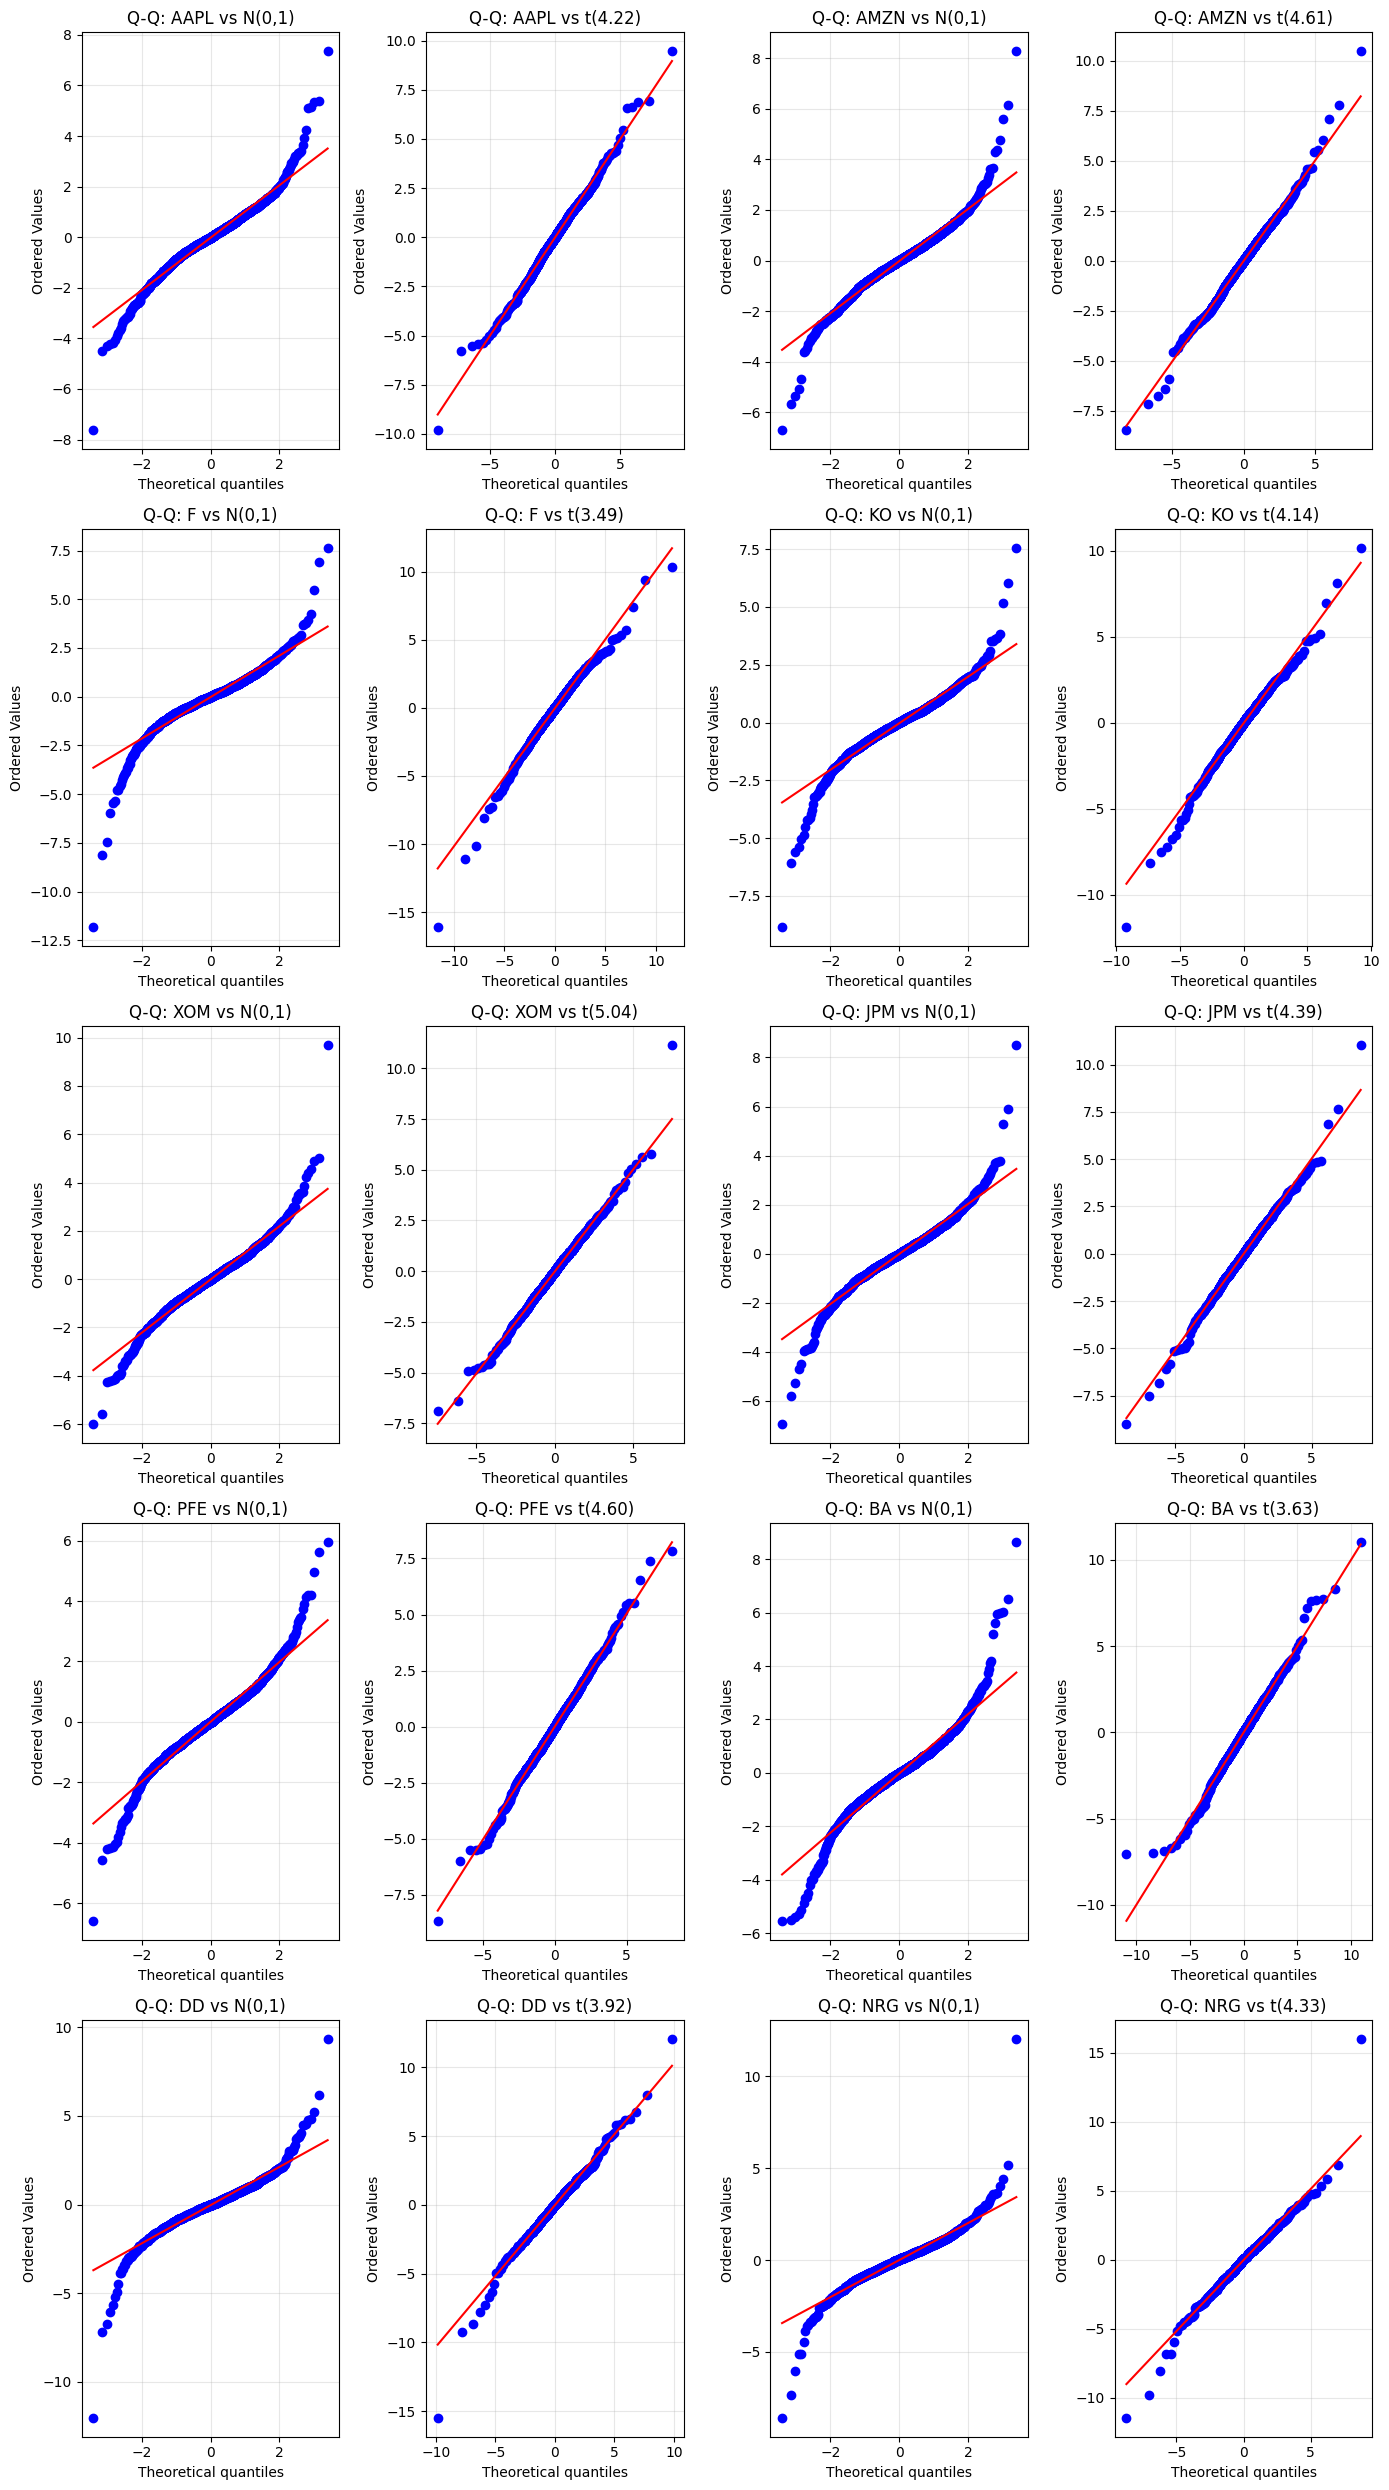

In [11]:
diag_df = qq_panel(my_picks,window_results)

In [12]:
diag_df

,n,ad_norm,ad_norm_p,ad_t_pit,ad_t_pit_p
ticker,,,,,
AAPL,2093,14.266370,0.01,0.715396,0.065126
AMZN,2093,12.012378,0.01,0.510309,0.150000
F,2093,25.881861,0.01,0.246208,0.150000
KO,2093,16.536270,0.01,0.574489,0.140365
XOM,2093,9.337234,0.01,0.301185,0.150000
JPM,2093,13.198095,0.01,0.175391,0.150000
PFE,2093,11.247993,0.01,0.257426,0.150000
BA,2093,20.314042,0.01,0.195912,0.150000
DD,2093,20.954902,0.01,0.372194,0.150000


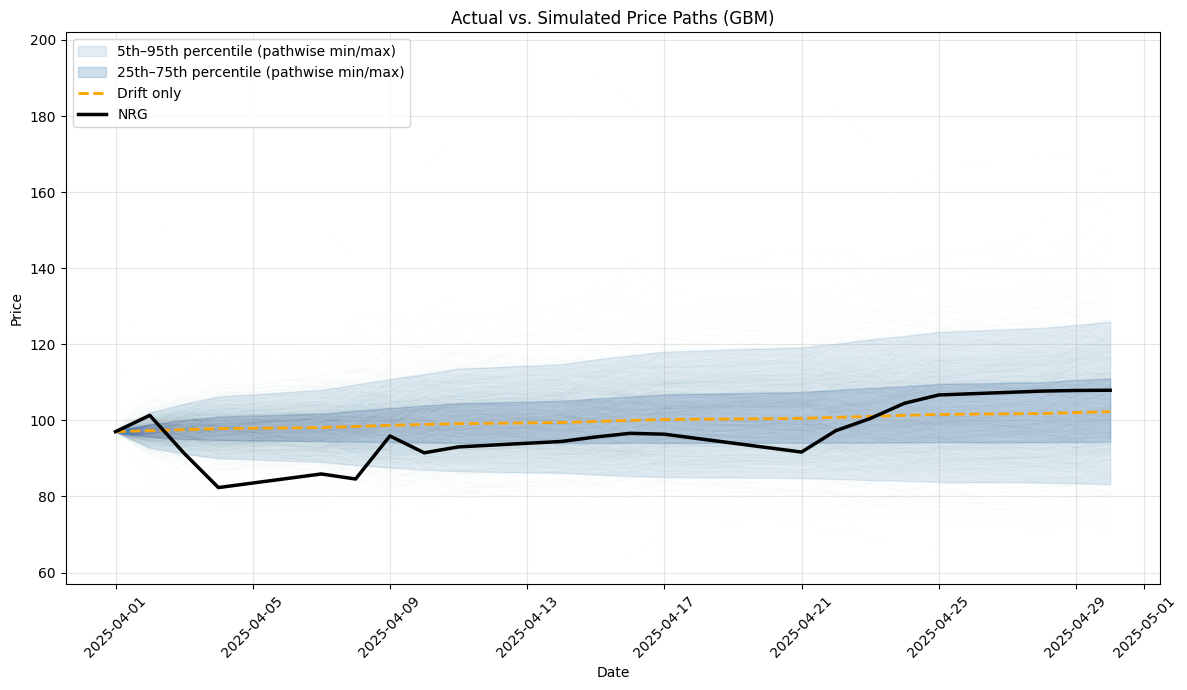

Overall Path Containment Stats (1000 trials):
p05    0.267
p25    0.623
p75    0.372
p95    0.794
dtype: float64


In [13]:
plot_bands_vs_actual(window,drift,bands,ticker,paths)
print(f'Overall Path Containment Stats ({path_containment.shape[0]} trials):\n',
      path_containment.mean(),sep='')